In [2]:
import joblib
import shap
import pandas as pd

/Users/telmomm/Desktop/TFM/Modelo Predictivo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

def model_predict(X):
    X_transformed = preprocessor.transform(X)
    return final_model.predict_proba(X_transformed)

explainer = joblib.load('explainer.joblib')

model = joblib.load('model.joblib')
preprocessor = model.named_steps['preprocessor']
final_model = model.named_steps['regressor']


/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/pickle.py:1760: UserWarning: [17:06:42] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [9]:
caracteristicas_paciente = {
    'Case': 'Paciente 1',
    'Creatininapre': 1.01,
    'Estanciahospitalariacalculada': 2.0,
    'Htopre': 34.2,
    'ComplicacionesMACE': 1.0,
    'ComplicacionesTODAS': 1.0,
    'Edmonton': 7.0
}

nombre_variables = {
        'Creatininapre': 'Creatinine',
        'Estanciahospitalariacalculada': 'Stay Length',
        'Htopre': 'Hematocrit',
        'ComplicacionesMACE': 'MACE',
        'ComplicacionesTODAS': 'Complications'
    }

caracteristicas_requeridas = [
        'Creatininapre', 'Estanciahospitalariacalculada', 'Htopre',
        'ComplicacionesMACE', 'ComplicacionesTODAS', 'Edmonton'
    ]
for caracteristica in caracteristicas_requeridas:
        if caracteristica not in caracteristicas_paciente:
            raise ValueError(f"Falta la característica requerida: {caracteristica}")

    # DataFrame con nombres originales para predicción y explainer
paciente_df = pd.DataFrame([caracteristicas_paciente])
paciente_df = paciente_df[caracteristicas_requeridas]

prediccion_proba = model_predict(paciente_df)
shap_values_paciente = explainer(paciente_df)

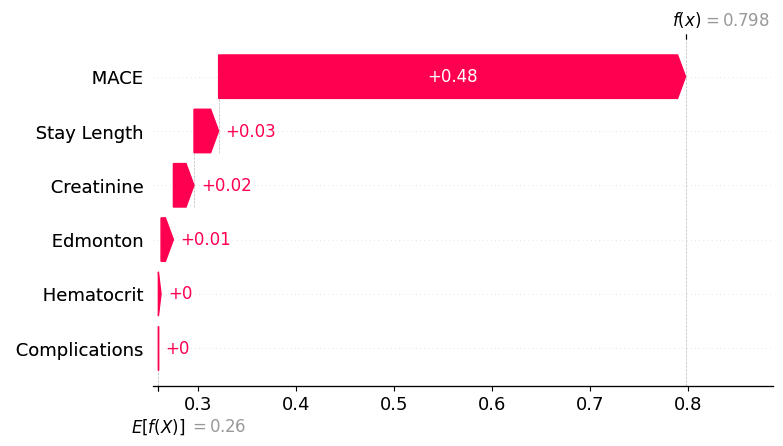

In [10]:
 # Renombrar SOLO para la visualización
paciente_df_viz = paciente_df.rename(columns=nombre_variables)
feature_names_viz = list(paciente_df_viz.columns)
shap.plots._waterfall.waterfall_legacy(
    expected_value = shap_values_paciente.base_values[0,1],
    shap_values=shap_values_paciente.values[0, :, 1],
    feature_names=feature_names_viz,
    features=paciente_df_viz.iloc[0].values
)
